In [22]:
import h5py
import gc
from glob import glob
import numpy as np
from matplotlib import pylab as plt
import cv2
import tensorflow as tf
print(tf.__version__)
from  tensorflow.keras.layers import *
from tensorflow.keras.initializers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model
from skimage import exposure
from sklearn.preprocessing import StandardScaler
import time
import os
from sklearn.model_selection import train_test_split
import joblib
from matplotlib import pyplot

2.15.0


In [17]:
dataset = h5py.File('train.h5', 'r')
X = dataset["x"]
y = dataset["y"]

X.shape, y.shape



((9245, 256, 256, 6), (9245, 256, 256, 6))

In [4]:
def contrast(image):
    for band_idx in range(image.shape[-1]):
        band_data = image[:,:,band_idx]
        valid_data = band_data[np.logical_and(band_data != np.inf, band_data != -np.inf)]
        in_low, in_high = np.percentile(valid_data, (2, 98))
        
        band_data = exposure.rescale_intensity(band_data, in_range=(in_low, in_high))
        image[:,:,band_idx] = band_data
        
    return image


In [43]:
img = cv2.imread('im.png')

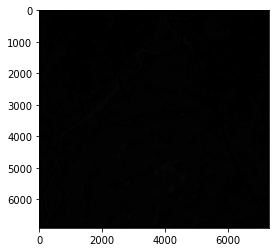

In [46]:
plt.imshow(img)
plt.show()

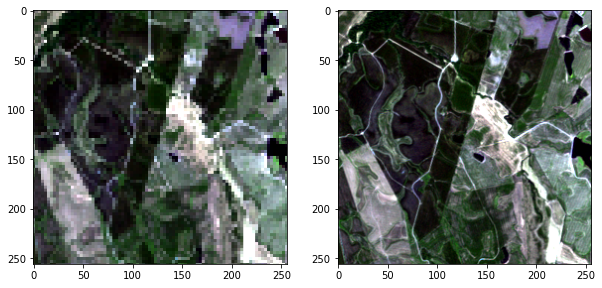

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(10, 8))

axs[0].imshow(contrast(X[125][:,:, :3] / 10000))
axs[1].imshow(contrast(y[125][:,:, :3] / 10000))


In [6]:

def load_data(batch_size):
    i=np.random.randint(0,int(len(X)/batch_size))
    
    img_A=(np.array(X[i:i+batch_size]) / 5000.0) - 1
    img_B=(np.array(y[i:i+batch_size]) / 5000.0) - 1

    return img_A,img_B

def load_batch(batch_size):
    
    for i in range(int(len(X)/batch_size)):
        img_A=(X[i:i+batch_size] / 5000.0) - 1
        img_B=(y[i:i+batch_size] / 5000.0) - 1

        yield img_A,img_B



In [7]:
def define_discriminator(image_shape):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # source image input
    in_src_image = Input(shape=image_shape)
    # target image input
    in_target_image = Input(shape=image_shape)
    # concatenate images channel-wise
    merged = Concatenate()([in_src_image, in_target_image])
    # C64
    d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
    d = LeakyReLU(alpha=0.2)(d)
    # C128
    d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    # C256
    d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    # C512
    d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    # second last output layer
    d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)
    # patch output
    d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
    patch_out = Activation('sigmoid')(d)
    # define model
    model = Model([in_src_image, in_target_image], patch_out)
    # compile model
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
    return model

In [8]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # add downsampling layer
    g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
    # conditionally add batch normalization
    if batchnorm:
        g = BatchNormalization()(g, training=True)
    # leaky relu activation
    g = LeakyReLU(alpha=0.2)(g)
    return g

# define a decoder block
def decoder_block(layer_in, skip_in, n_filters, dropout=True):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # add upsampling layer
    g = Conv2DTranspose(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
    # add batch normalization
    g = BatchNormalization()(g, training=True)
    # conditionally add dropout
    if dropout:
        g = Dropout(0.5)(g, training=True)
    # merge with skip connection
    g = Concatenate()([g, skip_in])
    # relu activation
    g = Activation('relu')(g)
    return g

# define the standalone generator model
def define_generator(image_shape):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # image input
    in_image = Input(shape=image_shape)
    # encoder model
    e1 = define_encoder_block(in_image, 64, batchnorm=False)
    e2 = define_encoder_block(e1, 128)
    e3 = define_encoder_block(e2, 256)
    e4 = define_encoder_block(e3, 512)
    e5 = define_encoder_block(e4, 512)
    e6 = define_encoder_block(e5, 512)
    e7 = define_encoder_block(e6, 512)
    # bottleneck, no batch norm and relu
    b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e7)
    b = Activation('relu')(b)
    # decoder model
    d1 = decoder_block(b, e7, 512)
    d2 = decoder_block(d1, e6, 512)
    d3 = decoder_block(d2, e5, 512)
    d4 = decoder_block(d3, e4, 512, dropout=False)
    d5 = decoder_block(d4, e3, 256, dropout=False)
    d6 = decoder_block(d5, e2, 128, dropout=False)
    d7 = decoder_block(d6, e1, 64, dropout=False)
    # output
    g = Conv2DTranspose(image_shape[-1], (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d7)
    out_image = Activation('tanh')(g)
    # define model
    model = Model(in_image, out_image)
    return model

In [9]:
def define_gan(g_model, d_model, image_shape):
    # make weights in the discriminator not trainable
    for layer in d_model.layers:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = False
    # define the source image
    in_src = Input(shape=image_shape)
    # connect the source image to the generator input
    gen_out = g_model(in_src)
    # connect the source input and generator output to the discriminator input
    dis_out = d_model([in_src, gen_out])
    # src image as input, generated image and classification output
    model = Model(in_src, [dis_out, gen_out])
    # compile model
    opt = Adam(lr=0.0002, beta_1=0.5)
    model.compile(loss=['binary_crossentropy', 'mae'], optimizer=opt, loss_weights=[1,100])
    return model


In [10]:
# select a batch of random samples, returns images and target
def generate_real_samples(n_samples, patch_shape):
    # unpack dataset
    trainA, trainB = load_data(n_samples)
    # choose random instances
    ix = np.random.randint(0, trainA.shape[0], n_samples)
    # retrieve selected images
    X1, X2 = trainA[ix], trainB[ix]
    # generate 'real' class labels (1)
    y = np.ones((n_samples, patch_shape, patch_shape, 1))
    return [X1, X2], y

In [11]:
# generate a batch of images, returns images and targets
def generate_fake_samples(g_model, samples, patch_shape):
    # generate fake instance
    X = g_model.predict(samples)
    # create 'fake' class labels (0)
    y = np.zeros((len(X), patch_shape, patch_shape, 1))
    return X, y



In [12]:
def summarize_performance(step, g_model, logs_dir, n_samples):
    r, c = 3, n_samples
    
    # select a sample of input images
    [X_realA, X_realB], _ = generate_real_samples(n_samples, 1)
    
    # generate a batch of fake samples
    X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
    
    gen_imgs = np.concatenate([X_realA, X_fakeB, X_realB])

    titles = ['Condition', 'Generated', 'Original']
    fig, axs = plt.subplots(r, c, figsize=(20,20))
    cnt = 0
    for i in range(r):
        for j in range(c):
            image = gen_imgs[cnt]

            reescaled_image = (image + 1) * 5000

            rgb_image = reescaled_image[:,:, :3]

            axs[i,j].imshow(contrast(rgb_image/10000))
            axs[i,j].set_title(titles[i])
            axs[i,j].axis('off')
            cnt += 1
            
    filename = '%s/plot_%06d.png' % (logs_dir, step)
    fig.savefig(filename)
    plt.show()

In [13]:
 #train pix2pix model
def train(d_model, g_model, gan_model, n_epochs, n_batch, logs_dir, d_filename, g_filename):
    
    # determine the output square shape of the discriminator
    n_patch = d_model.output_shape[1]
    
    # unpack dataset
    for epoch in range(1, n_epochs + 1):
        for batch_i,(trainA,trainB) in enumerate(load_batch(n_batch)):
            
            # select a batch of real samples
            [X_realA, X_realB], y_real = generate_real_samples(n_batch, n_patch)

            # generate a batch of fake samples
            X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)
            
            # update discriminator for real samples
            d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
            
            # update discriminator for generated samples
            d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)
            
            # update the generator
            g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])
            
            # summarize performance
            print(f'[Epoch {epoch}] [Batch {batch_i}] [D1 loss: {d_loss1}] [D2 loss: {d_loss2}] [G loss: {g_loss}]')
        
        # summarize model performance
        summarize_performance(epoch, g_model, logs_dir, n_samples=3)
        # save the generator model
        g_model.save(d_filename)

        # save the discriminator model        
        d_model.save(d_filename)

In [14]:
# load image data
image_shape = (256, 256, 6)

# define the models
d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)

# save or reload models
logs_dir = '/kaggle/working/logs'
if not os.path.exists(logs_dir):
    os.mkdir(logs_dir)

g_filename = f'{logs_dir}/g_model.h5'
d_filename = f'{logs_dir}/d_model.h5'

if os.path.exists(g_filename):
    g_model.load_model(g_filename)
    
if os.path.exists(d_filename):
    d_model.load_model(d_filename)

# define the composite model
gan_model = define_gan(g_model, d_model, image_shape)

# train model
train(d_model, g_model, gan_model, n_epochs=20, n_batch=32, 
      logs_dir=logs_dir, d_filename=d_filename, g_filename=g_filename)

/home/wiredu/.local/lib/python3.9/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/logs'

In [3]:
!pip install rasterio

     |▌                               | 337 kB 4.6 kB/s eta 1:16:16ERROR: Exception:
Traceback (most recent call last):
  File "/usr/share/python-wheels/resolvelib-0.5.4-py2.py3-none-any.whl/resolvelib/resolvers.py", line 171, in _merge_into_criterion
    crit = self.state.criteria[name]
KeyError: 'rasterio'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/share/python-wheels/urllib3-1.26.5-py2.py3-none-any.whl/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/usr/share/python-wheels/urllib3-1.26.5-py2.py3-none-any.whl/urllib3/response.py", line 519, in read
    data = self._fp.read(amt) if not fp_closed else b""
  File "/usr/share/python-wheels/CacheControl-0.12.6-py2.py3-none-any.whl/cachecontrol/filewrapper.py", line 62, in read
    data = self.__fp.read(amt)
  File "/usr/lib/python3.9/http/client.py", line 458, in read
    n = self.readinto(b)
  File "/usr/lib/python3.9/http/client.py", line 502

In [1]:
import rasterio

ModuleNotFoundError: No module named 'rasterio'